# 

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Load training data
data_train = pd.read_csv('/home/bigbang/machinelearning_algorithms/polynomial_regression_train.csv')
X_train = data_train.iloc[:, 1:-1].values  # Features
y = data_train.iloc[:, -1].values    # Target

# Load test data (no target column)
data_test = pd.read_csv('/home/bigbang/machinelearning_algorithms/polynomial_regression_test.csv')
X_test = data_test.iloc[:, 1:].values  # Features

#checking if the data is loaded 
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y: {y.shape}")
print(f"Shape of X_test: {X_test.shape}")

#Normalization of data 
X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0)

X = (X_train - X_train_mean) / X_train_std  # Standardize training features of normalized test data
X_test = (X_test - X_train_mean) / X_train_std 

print("First few rows of normalized X_train:")
print(X[:5])
print(y[:5])





Shape of X_train: (48000, 5)
Shape of y: (48000,)
Shape of X_test: (12000, 5)
First few rows of normalized X_train:
[[-0.2714613   0.8506241  -1.08085056  0.36352986 -0.30120231]
 [-0.33649379 -1.02157784  0.53130124  0.04676399  0.60073514]
 [-1.08580695 -0.11957387 -0.0035855   0.42165651 -0.20624923]
 [-0.38456269 -1.49336953 -0.08711699  0.77562632  0.28089057]
 [-1.50619576  1.68733431  1.10358013 -0.41158349  0.91599346]]
[ 8.16874285e-10 -5.08122456e-10  4.56017046e-10 -2.64754585e-09
 -1.70460579e-08]


In [3]:
# Step 2: Define the polynomial regression function
def PolyReg_with_gradient_descent(X, y, alpha, epoch, degree):
    """
    Perform polynomial regression using gradient descent.
    """
    # Generate polynomial features
    X_poly = np.hstack([X ** i for i in range(1, degree + 1)])
    X_poly = np.c_[np.ones(X_poly.shape[0]), X_poly]  # Add bias term

    m = X_poly.shape[0]  # Number of samples
    n = X_poly.shape[1]  # Number of features
    w = np.ones(n)  # Initialize weights
    costs = []

    def compute_cost(X_poly, y, w):
       
        m = len(y)
        h = np.dot(X_poly, w)
        cost = (1 / (2 * m)) * np.sum((h - y) ** 2)
        return cost

    for i in range(epoch):
        h = np.dot(X_poly, w)  # Compute predictions
        gradient = (1 / m) * np.dot(X_poly.T, (h - y))  # Compute gradient
        w = w - alpha * gradient  # Update weights

        cost = compute_cost(X_poly, y, w)
        costs.append(cost)
        if i % 100 == 0:  # Print every 100 epochs
            print(f'Epoch {i}, Cost: {cost}')

    return w, costs, X_poly


In [4]:
# Step 3: Make predictions
def predict(X, w, degree):
   
    X_poly = np.hstack([X ** i for i in range(1, degree + 1)])
    X_poly = np.c_[np.ones(X_poly.shape[0]), X_poly]  # Add bias term
    predictions = np.dot(X_poly, w)
    return predictions


Epoch 0, Cost: 19.8665788803349
Epoch 100, Cost: 0.3292844107946414
Epoch 200, Cost: 0.044640805194563746
Epoch 300, Cost: 0.006308852498779346
Epoch 400, Cost: 0.0010859691452589622
Epoch 500, Cost: 0.0003314483527468062
Epoch 600, Cost: 0.00019001093985261425
Epoch 700, Cost: 0.00013985835831839901
Epoch 800, Cost: 0.0001086993619972643
Epoch 900, Cost: 8.532117478129885e-05


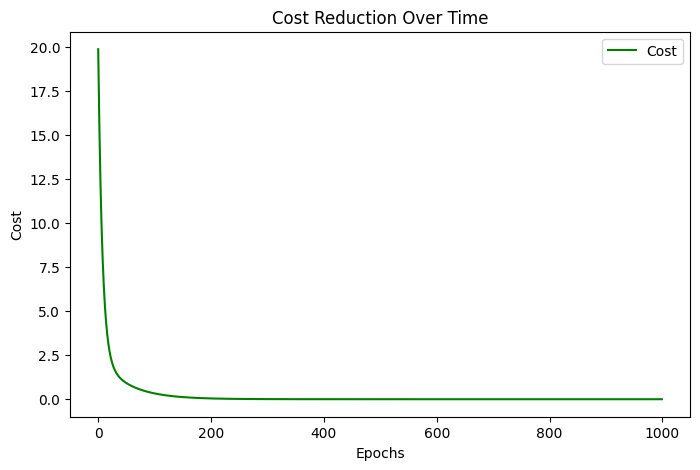

Predicted values = [ 0.0191722   0.02124698  0.02333898  0.01421287 -0.00888784]


In [17]:

# Hyperparameters
degree = 2
alpha = 0.01
epoch = 1000

# Train the model
weights, cost_history, X_poly = PolyReg_with_gradient_descent(X, y, alpha, epoch, degree)

# Plot cost reduction over epochs
plt.figure(figsize=(8, 5))
plt.plot(range(len(cost_history)), cost_history, color='green', label='Cost')
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Cost Reduction Over Time')
plt.legend()
plt.show()

# Make predictions
y_pred = predict(X, weights, degree)
print(f"Predicted values = {y_pred[:5]}")




In [18]:
def r2_score(y_true, y_pred):
   
    ss_total = np.sum((y_true - np.mean(y_true))**2)  # Total sum of squares
    ss_residual = np.sum((y_true - y_pred)**2)        # Residual sum of squares
    r2 = 1 - (ss_residual / ss_total)
    return r2

print(f"R² Score: {r2_score(y, y_pred)}")

R² Score: -1178882490873.603
